# DeepGPR temporal checkpoint example

This notebook demonstrates a **real recomputation checkpoint** for DeepGPR. The full time axis is split into segments; only the final E/H/CPML state of each segment remains in the autograd graph. During backward, `torch.utils.checkpoint` replays one segment so DeepGPR only needs that segment's FP32 wavefield history.

The default RTX 4090 case is intentionally large (`512 x 384`, 2200 time steps, 4 shots). The two uncheckpointed FP32 forward histories occupy about 12.89 GiB; together with the adjoint working allocation, the measured full peak should be close to 20 GiB. The notebook compares receiver data, material gradients, peak CUDA memory, and execution time.

> Important: DeepGPR updates E/H/CPML inputs in-place. Each segment therefore clones its boundary tensors before propagation. Removing those clones corrupts recomputation boundaries and gives incorrect gradients.


In [1]:
from pathlib import Path
import gc
import os
import sys
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp/deepgpr-matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore", message="IProgress not found.*")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch.utils.checkpoint import checkpoint

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, *cwd.parents]
REPO_ROOT = next(
    (path for path in candidates if (path / "src" / "DeepGPR").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError("Run this notebook from the DeepGPR repository or tests directory.")
sys.path.insert(0, str(REPO_ROOT / "src"))
for module_name in tuple(sys.modules):
    if module_name == "DeepGPR" or module_name.startswith("DeepGPR."):
        del sys.modules[module_name]
import DeepGPR

if not torch.cuda.is_available():
    raise RuntimeError("This example requires a CUDA GPU with about 21 GiB free.")

DEVICE = torch.device("cuda:0")
torch.manual_seed(20260825)
torch.cuda.set_device(DEVICE)
print(f"Repository: {REPO_ROOT}")
print(f"DeepGPR:   {Path(DeepGPR.__file__).resolve()}")
print(f"PyTorch:   {torch.__version__}")
print(f"GPU:       {torch.cuda.get_device_name(DEVICE)}")


Repository: /home/ll/下载/DeepGPR-dev
DeepGPR:   /home/ll/下载/DeepGPR-dev/src/DeepGPR/__init__.py
PyTorch:   1.11.0+cu115
GPU:       NVIDIA GeForce RTX 4090


## Large deterministic case

`model_gradient_sampling_interval=1` and FP32 storage make the uncheckpointed run the exact full-history reference. Change `segment_steps` to explore the memory/recomputation trade-off. Smaller segments reduce history memory but increase the number of saved boundary states and Python/native launches.


In [2]:
CONFIG = {
    "nx": 512,
    "ny": 384,
    "nt": 2200,
    "shots": 4,
    "receivers": 64,
    "segment_steps": 275,
    "pml": 20,
    "dx": 0.01,
    "dt": 1.5e-11,
    "frequency": 4.0e8,
    "peak_time": 2.5e-9,
}

nx, ny, nt = CONFIG["nx"], CONFIG["ny"], CONFIG["nt"]
shots, receivers = CONFIG["shots"], CONFIG["receivers"]
segment_steps = CONFIG["segment_steps"]

single_history_bytes = nt * shots * nx * ny * torch.finfo(torch.float32).bits // 8
history_bytes = 2 * single_history_bytes
estimated_full_peak_bytes = 3 * single_history_bytes
segment_history_bytes = 2 * segment_steps * shots * nx * ny * 4
free_bytes, total_bytes = torch.cuda.mem_get_info(DEVICE)
gib = 1024 ** 3
print(f"GPU total/free:              {total_bytes/gib:.2f} / {free_bytes/gib:.2f} GiB")
print(f"Full E/R history payload:    {history_bytes/gib:.2f} GiB")
print(f"Estimated full-run peak:     {estimated_full_peak_bytes/gib:.2f} GiB + small fixed buffers")
print(f"One segment history payload: {segment_history_bytes/gib:.2f} GiB")
print(f"Segments:                    {(nt + segment_steps - 1)//segment_steps}")
if free_bytes < estimated_full_peak_bytes + 1.0 * gib:
    raise RuntimeError(
        "Not enough free CUDA memory for the default ~20 GiB reference. "
        "Close other GPU processes or lower CONFIG['nt']."
    )

x = torch.linspace(0.0, 1.0, nx, device=DEVICE)[:, None]
y = torch.linspace(0.0, 1.0, ny, device=DEVICE)[None, :]
epsilon_base = (
    5.0
    + 1.6 * torch.exp(-((x - 0.38) ** 2 + (y - 0.58) ** 2) / 0.018)
    - 0.7 * torch.exp(-((x - 0.70) ** 2 + (y - 0.68) ** 2) / 0.012)
).float()
sigma_base = (
    7.0e-4
    + 3.0e-4 * y
    + 2.0e-4 * torch.exp(-((x - 0.63) ** 2 + (y - 0.50) ** 2) / 0.025)
).float()

source_amplitudes = DeepGPR.wavelet.ricker(
    CONFIG["frequency"], nt, CONFIG["dt"], CONFIG["peak_time"],
    device=DEVICE,
).reshape(1, nt, 1)
source_location = torch.zeros((shots, 1, 3), dtype=torch.int32, device=DEVICE)
receiver_location = torch.zeros(
    (shots, receivers, 3), dtype=torch.int32, device=DEVICE
)
shot_x = torch.linspace(CONFIG["pml"] + 2, nx - CONFIG["pml"] - 3, shots, device=DEVICE).round().int()
receiver_x = torch.linspace(CONFIG["pml"] + 2, nx - CONFIG["pml"] - 3, receivers, device=DEVICE).round().int()
source_location[:, 0, 0] = shot_x
source_location[:, 0, 1] = CONFIG["pml"] + 2
receiver_location[:, :, 0] = receiver_x
receiver_location[:, :, 1] = CONFIG["pml"] + 2

COMMON = dict(
    device=DEVICE,
    dx=CONFIG["dx"],
    dt=CONFIG["dt"],
    source_location=source_location,
    receiver_location=receiver_location,
    pmlthick=CONFIG["pml"],
    source_direction=2,
    receiver_component=2,
    fdtd_order=2,
    mode=2,
    model_gradient_sampling_interval=1,
    wavefield_storage_dtype=torch.float32,
    wavefield_compression="none",
)


GPU total/free:              23.50 / 22.28 GiB
Full E/R history payload:    12.89 GiB
Estimated full-run peak:     19.34 GiB + small fixed buffers
One segment history payload: 1.61 GiB
Segments:                    8


## Checkpointed temporal propagation

Every checkpointed function returns 30 boundary tensors (3 E, 3 H, and 24 CPML states) plus that segment's receiver traces. On the first forward pass, PyTorch discards the segment's internal autograd graph and its large wavefield histories. Backward replays the segment and immediately applies DeepGPR's native adjoint.


In [3]:
STATE_TENSOR_COUNT = 30

def checkpointed_forward(epsilon, sigma, source):
    state = ()
    receiver_segments = []

    for start in range(0, source.shape[1], segment_steps):
        source_segment = source[:, start:start + segment_steps, :].contiguous()

        def advance_segment(er, se, source_chunk, *boundary):
            # DeepGPR advances state tensors in-place. Preserve the immutable
            # checkpoint input by propagating from differentiable clones.
            work_state = tuple(tensor.clone() for tensor in boundary)
            electric = work_state[:3] if work_state else None
            magnetic = work_state[3:6] if work_state else None
            cpml = work_state[6:] if work_state else None
            result = DeepGPR.compute(
                er=er,
                se=se,
                source_amplitudes=source_chunk,
                E=electric,
                H=magnetic,
                PML=cpml,
                **COMMON,
            )
            return (*result[1], *result[2], *result[3], result[-1])

        outputs = checkpoint(
            advance_segment,
            epsilon,
            sigma,
            source_segment,
            *state,
            preserve_rng_state=False,
        )
        state = outputs[:STATE_TENSOR_COUNT]
        receiver_segments.append(outputs[STATE_TENSOR_COUNT])

    return torch.cat(receiver_segments, dim=1)


def ordinary_forward(epsilon, sigma, source):
    return DeepGPR.compute(
        er=epsilon,
        se=sigma,
        source_amplitudes=source,
        **COMMON,
    )[-1]


## Run both forward/backward paths and record CUDA memory

Peak values below come from `torch.cuda.max_memory_allocated` and `max_memory_reserved`, synchronized around each phase. They are printed and stored directly in the notebook output. A no-history forward creates a fixed synthetic target without contributing a gradient graph.


In [4]:
def cleanup_cuda():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize(DEVICE)


cleanup_cuda()
with torch.no_grad():
    reference_data = DeepGPR.compute(
        er=epsilon_base,
        se=sigma_base,
        source_amplitudes=source_amplitudes,
        save_wavefield_history=False,
        **COMMON,
    )[-1].detach()
target_data = 0.85 * reference_data
data_scale = reference_data.abs().max().clamp_min(1.0e-12)
print(f"Target trace scale: {float(data_scale):.6e}")


def run_and_measure(label, use_checkpoint):
    cleanup_cuda()
    epsilon = epsilon_base.detach().clone().requires_grad_(True)
    sigma = sigma_base.detach().clone().requires_grad_(True)
    torch.cuda.reset_peak_memory_stats(DEVICE)

    total_start = torch.cuda.Event(enable_timing=True)
    forward_end = torch.cuda.Event(enable_timing=True)
    backward_start = torch.cuda.Event(enable_timing=True)
    backward_end = torch.cuda.Event(enable_timing=True)

    total_start.record()
    if use_checkpoint:
        receiver = checkpointed_forward(epsilon, sigma, source_amplitudes)
    else:
        receiver = ordinary_forward(epsilon, sigma, source_amplitudes)
    forward_end.record()
    torch.cuda.synchronize(DEVICE)
    forward_peak_allocated = torch.cuda.max_memory_allocated(DEVICE) / gib

    residual = (receiver - target_data) / data_scale
    loss = 0.5 * residual.square().sum()
    backward_start.record()
    loss.backward()
    backward_end.record()
    torch.cuda.synchronize(DEVICE)

    result = {
        "method": label,
        "receiver": receiver.detach().cpu(),
        "grad_epsilon": epsilon.grad.detach().cpu(),
        "grad_sigma": sigma.grad.detach().cpu(),
        "loss": float(loss.detach()),
        "forward_peak_allocated_gib": forward_peak_allocated,
        "peak_allocated_gib": torch.cuda.max_memory_allocated(DEVICE) / gib,
        "peak_reserved_gib": torch.cuda.max_memory_reserved(DEVICE) / gib,
        "forward_ms": total_start.elapsed_time(forward_end),
        "backward_ms": backward_start.elapsed_time(backward_end),
        "total_ms": total_start.elapsed_time(backward_end),
    }
    print(
        f"{label:22s} | peak allocated {result['peak_allocated_gib']:6.2f} GiB | "
        f"peak reserved {result['peak_reserved_gib']:6.2f} GiB | "
        f"total {result['total_ms']:8.2f} ms"
    )
    del receiver, residual, loss, epsilon, sigma
    cleanup_cuda()
    return result


ordinary = run_and_measure("without checkpoint", use_checkpoint=False)
checkpointed = run_and_measure("with checkpoint", use_checkpoint=True)


Target trace scale: 1.849704e+03


without checkpoint     | peak allocated  19.40 GiB | peak reserved  19.42 GiB | total   382.70 ms


with checkpoint        | peak allocated   2.80 GiB | peak reserved   3.34 GiB | total   616.69 ms


## Numerical and gradient validity

The checkpointed receiver samples should match exactly because temporal segmentation does not change the FDTD operations. Material gradients can differ by a few FP32 rounding units because segment-wise adjoints accumulate contributions in a different order.


In [5]:
def comparison_metrics(reference, candidate):
    reference = reference.float().reshape(-1)
    candidate = candidate.float().reshape(-1)
    difference = candidate - reference
    relative_l2 = float(difference.norm() / reference.norm().clamp_min(1.0e-30))
    max_abs = float(difference.abs().max())
    cosine = float(torch.nn.functional.cosine_similarity(reference, candidate, dim=0))
    return relative_l2, max_abs, cosine


comparison_rows = []
for name, key in (
    ("receiver data", "receiver"),
    ("epsilon gradient", "grad_epsilon"),
    ("sigma gradient", "grad_sigma"),
):
    rel_l2, max_abs, cosine = comparison_metrics(ordinary[key], checkpointed[key])
    comparison_rows.append(
        {
            "quantity": name,
            "relative L2": rel_l2,
            "max abs difference": max_abs,
            "cosine similarity": cosine,
        }
    )
comparison_df = pd.DataFrame(comparison_rows).set_index("quantity")
with pd.option_context("display.precision", 8):
    display(comparison_df)

assert comparison_rows[0]["relative L2"] <= 1.0e-7, "Receiver data mismatch"
assert comparison_rows[1]["relative L2"] <= 2.0e-5, "epsilon gradient mismatch"
assert comparison_rows[2]["relative L2"] <= 2.0e-5, "sigma gradient mismatch"
assert comparison_rows[1]["cosine similarity"] >= 0.99999
assert comparison_rows[2]["cosine similarity"] >= 0.99999
print("PASS: checkpointed data and material gradients agree with the full-history reference.")


,relative L2,max abs difference,cosine similarity
quantity,,,
receiver data,0.00000000,0.00000000,1.00000000
epsilon gradient,0.00000022,0.00000001,1.00000000
sigma gradient,0.00000028,0.00000048,0.99999994


PASS: checkpointed data and material gradients agree with the full-history reference.


## Memory and runtime shown in the notebook


,forward peak allocated (GiB),full peak allocated (GiB),peak reserved (GiB),forward (ms),backward (ms),total (ms)
method,,,,,,
without checkpoint,12.952,19.403,19.424,149.256,233.086,382.704
with checkpoint,1.946,2.797,3.344,219.250,397.135,616.690


Peak allocated memory saved: 16.61 GiB (85.6%)
Checkpoint total-time ratio: 1.61x


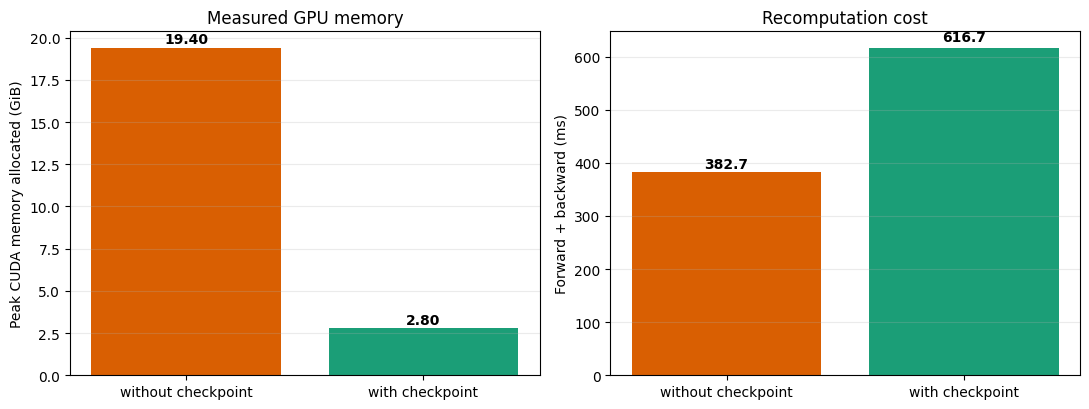

In [6]:
memory_df = pd.DataFrame(
    [
        {
            "method": run["method"],
            "forward peak allocated (GiB)": run["forward_peak_allocated_gib"],
            "full peak allocated (GiB)": run["peak_allocated_gib"],
            "peak reserved (GiB)": run["peak_reserved_gib"],
            "forward (ms)": run["forward_ms"],
            "backward (ms)": run["backward_ms"],
            "total (ms)": run["total_ms"],
        }
        for run in (ordinary, checkpointed)
    ]
).set_index("method")
with pd.option_context("display.precision", 3):
    display(memory_df)

saved_gib = ordinary["peak_allocated_gib"] - checkpointed["peak_allocated_gib"]
saved_percent = 100.0 * saved_gib / ordinary["peak_allocated_gib"]
runtime_ratio = checkpointed["total_ms"] / ordinary["total_ms"]
print(f"Peak allocated memory saved: {saved_gib:.2f} GiB ({saved_percent:.1f}%)")
print(f"Checkpoint total-time ratio: {runtime_ratio:.2f}x")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
labels = ["without checkpoint", "with checkpoint"]
colors = ["#d95f02", "#1b9e77"]
axes[0].bar(labels, [ordinary["peak_allocated_gib"], checkpointed["peak_allocated_gib"]], color=colors)
axes[0].set_ylabel("Peak CUDA memory allocated (GiB)")
axes[0].set_title("Measured GPU memory")
axes[0].grid(axis="y", alpha=0.25)
for index, value in enumerate([ordinary["peak_allocated_gib"], checkpointed["peak_allocated_gib"]]):
    axes[0].text(index, value + 0.25, f"{value:.2f}", ha="center", fontweight="bold")
axes[1].bar(labels, [ordinary["total_ms"], checkpointed["total_ms"]], color=colors)
axes[1].set_ylabel("Forward + backward (ms)")
axes[1].set_title("Recomputation cost")
axes[1].grid(axis="y", alpha=0.25)
for index, value in enumerate([ordinary["total_ms"], checkpointed["total_ms"]]):
    axes[1].text(index, value * 1.02, f"{value:.1f}", ha="center", fontweight="bold")
fig.tight_layout()
plt.show()


## Receiver and gradient visualizations


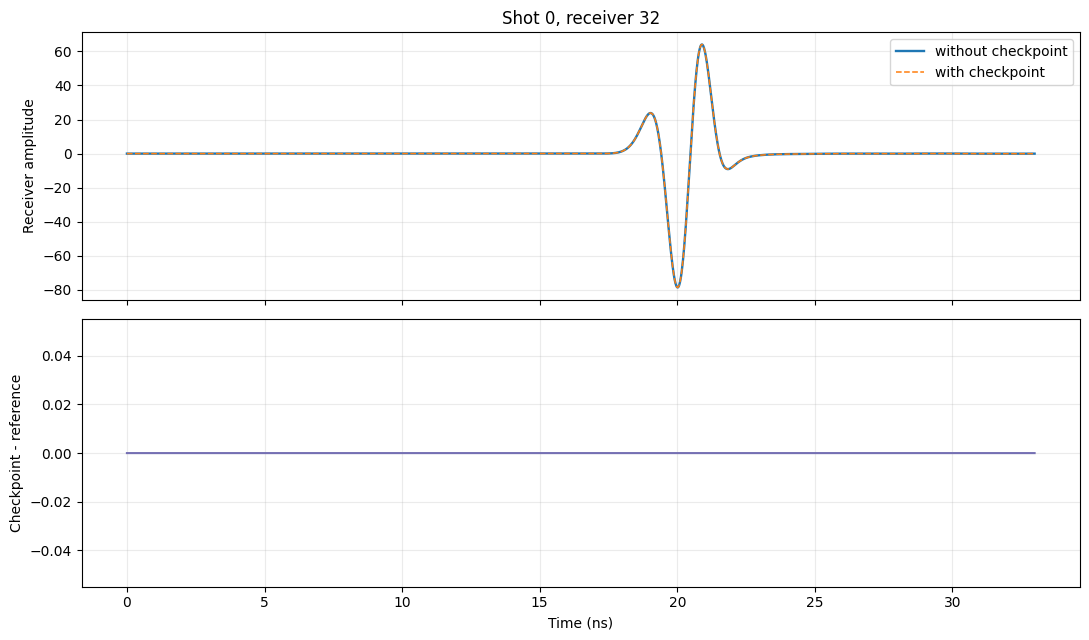

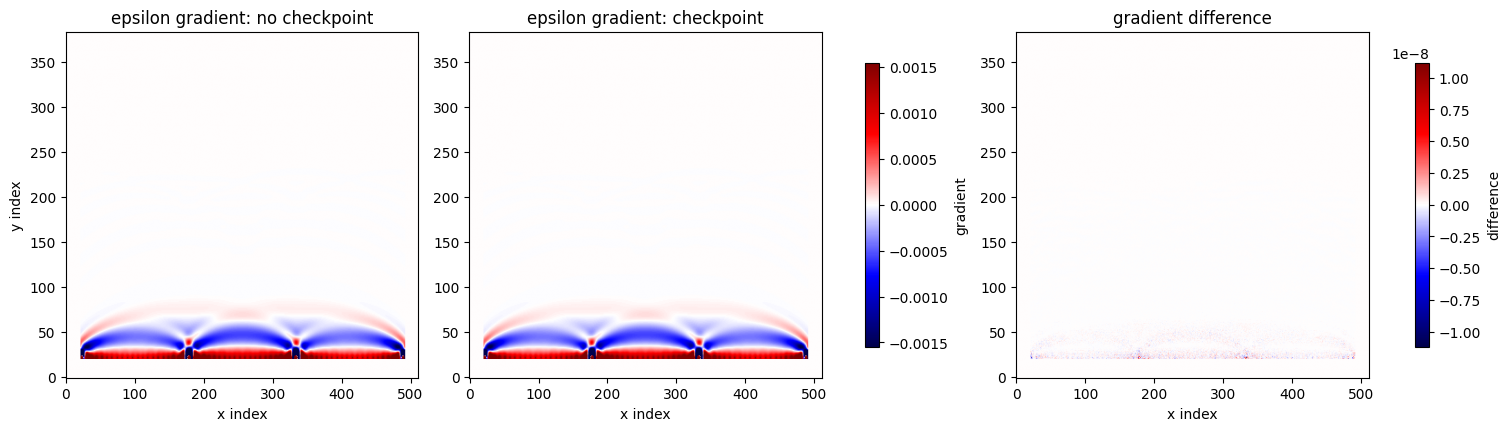

In [7]:
shot_index = 0
receiver_index = receivers // 2
time_ns = np.arange(nt) * CONFIG["dt"] * 1.0e9
trace_plain = ordinary["receiver"][shot_index, :, receiver_index].numpy()
trace_checkpoint = checkpointed["receiver"][shot_index, :, receiver_index].numpy()

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
axes[0].plot(time_ns, trace_plain, label="without checkpoint", linewidth=1.7)
axes[0].plot(time_ns, trace_checkpoint, "--", label="with checkpoint", linewidth=1.1)
axes[0].set_ylabel("Receiver amplitude")
axes[0].set_title(f"Shot {shot_index}, receiver {receiver_index}")
axes[0].legend()
axes[0].grid(alpha=0.25)
axes[1].plot(time_ns, trace_checkpoint - trace_plain, color="#7570b3")
axes[1].set_xlabel("Time (ns)")
axes[1].set_ylabel("Checkpoint - reference")
axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

grad_plain = ordinary["grad_epsilon"].numpy()
grad_checkpoint = checkpointed["grad_epsilon"].numpy()
grad_difference = grad_checkpoint - grad_plain
limit = np.percentile(np.abs(grad_plain), 99.5)
difference_limit = max(np.max(np.abs(grad_difference)), np.finfo(np.float32).tiny)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
images = [
    axes[0].imshow(grad_plain.T, origin="lower", cmap="seismic", vmin=-limit, vmax=limit, aspect="auto"),
    axes[1].imshow(grad_checkpoint.T, origin="lower", cmap="seismic", vmin=-limit, vmax=limit, aspect="auto"),
    axes[2].imshow(grad_difference.T, origin="lower", cmap="seismic", vmin=-difference_limit, vmax=difference_limit, aspect="auto"),
]
axes[0].set_title("epsilon gradient: no checkpoint")
axes[1].set_title("epsilon gradient: checkpoint")
axes[2].set_title("gradient difference")
for axis in axes:
    axis.set_xlabel("x index")
axes[0].set_ylabel("y index")
fig.colorbar(images[0], ax=axes[:2], shrink=0.82, label="gradient")
fig.colorbar(images[2], ax=axes[2], shrink=0.82, label="difference")
plt.show()


## Interpretation

A valid run must satisfy all assertions above. The receiver overlay and gradient maps establish numerical equivalence; the memory chart demonstrates the benefit of retaining only temporal boundary states. The runtime ratio is measured rather than assumed: checkpointing normally trades extra forward recomputation and launches for a much lower peak allocation.
